# Exercise 5

Student: Konstantinos Kritsotakis

Registration Number: 7115152500007  

Course: Image Analysis and Processing (2025–2026) 

## Question (a) — Estimated Forward Enhancement Pipeline from Image 1 to Image 2

The goal of this part is to infer a plausible sequence of spatial-domain enhancement operations that could transform **Image 1** into **Image 2**.

By visually comparing the two images, Image 2 appears to be:

- a negative-like version of Image 1,
- much brighter than Image 1,
- strongly enhanced in contrast,
- sharper around anatomical boundaries and edges,
- affected by fine-grained noise,
- clipped/saturated in several bright regions.

Therefore, a reasonable forward model is a combination of:

1. negative transformation,
2. gamma correction,
3. brightness and contrast enhancement,
4. Laplacian sharpening,
5. fine Gaussian noise addition or noise amplification,
6. clipping to the 8-bit intensity range.

The proposed processing sequence is:

$$
I_1
\rightarrow
I_{\text{neg}}
\rightarrow
I_{\gamma}
\rightarrow
I_{\text{bright}}
\rightarrow
I_{\text{sharp}}
\rightarrow
I_{2,\text{simulated}}
$$

where \(I_1\) is the original X-ray image and \(I_{2,\text{simulated}}\) is the simulated approximation of Image 2.

---

## 1. Negative Transformation

The first and most important transformation is an intensity inversion:

$$
I_{\text{neg}}(x,y)=255-I_1(x,y)
$$

This operation converts dark pixels into bright pixels and bright pixels into dark pixels.

For example:

$$
I_1(x,y)=30
\Rightarrow
I_{\text{neg}}(x,y)=255-30=225
$$

This explains why the lungs, which are dark in the original X-ray, become bright in Image 2.

---

## 2. Gamma Correction

After the negative transformation, gamma correction is applied in order to increase the brightness of mid-range and relatively dark intensities.

The general gamma transformation is:

$$
I_{\gamma}(x,y)
=
255
\left(
\frac{I_{\text{neg}}(x,y)}{255}
\right)^{\gamma}
$$

In this implementation:

$$
\gamma = 0.6
$$

Since:

$$
0<\gamma<1
$$

the transformation brightens the image, especially the middle gray-level values.

Therefore:

$$
I_{\gamma}(x,y)
=
255
\left(
\frac{I_{\text{neg}}(x,y)}{255}
\right)^{0.6}
$$

This step helps reproduce the high overall brightness observed in Image 2.

---

## 3. Brightness and Contrast Enhancement

A linear gray-level transformation is then applied:

$$
I_{\text{bright}}(x,y)
=
\text{clip}
\left(
\alpha I_{\gamma}(x,y)+\beta,\ 0,\ 255
\right)
$$

where:

- \(\alpha\) controls contrast,
- \(\beta\) controls brightness,
- \(\text{clip}(\cdot,0,255)\) restricts all values to the valid 8-bit range.

In the implemented pipeline:

$$
\alpha = 1.25
$$

and:

$$
\beta = 25
$$

Thus:

$$
I_{\text{bright}}(x,y)
=
\text{clip}
\left(
1.25 I_{\gamma}(x,y)+25,\ 0,\ 255
\right)
$$

The parameter \(\alpha>1\) increases intensity differences between pixels, therefore increasing contrast.

The parameter \(\beta>0\) shifts intensities upward, therefore increasing brightness.

The clipping operation is necessary because some transformed values may exceed 255:

$$
I(x,y)>255
\Rightarrow
I(x,y)=255
$$

This explains the saturation and very bright areas observed in Image 2.

---

## 4. Laplacian Sharpening

Image 2 also shows stronger anatomical edges and local structures. This suggests the use of a sharpening spatial filter.

A plausible sharpening method is Laplacian sharpening.

The Laplacian operator is a second-order derivative operator:

$$
\nabla^2 I
=
\frac{\partial^2 I}{\partial x^2}
+
\frac{\partial^2 I}{\partial y^2}
$$

In discrete form, the following Laplacian kernel is used:

$$
L=
\begin{bmatrix}
0 & -1 & 0 \\
-1 & 4 & -1 \\
0 & -1 & 0
\end{bmatrix}
$$

This kernel computes:

$$
\nabla^2 I(x,y)
=
4I(x,y)
-
I(x-1,y)
-
I(x+1,y)
-
I(x,y-1)
-
I(x,y+1)
$$

The Laplacian response is computed as:

$$
\text{lap}(x,y)
=
I_{\text{bright}}(x,y) * L
$$

where \(*\) denotes convolution.

Then sharpening is performed by adding a scaled Laplacian response to the image:

$$
I_{\text{sharp}}(x,y)
=
\text{clip}
\left(
I_{\text{bright}}(x,y)
+
\lambda \cdot \text{lap}(x,y),\ 0,\ 255
\right)
$$

In the implemented pipeline:

$$
\lambda = 0.45
$$

Therefore:

$$
I_{\text{sharp}}(x,y)
=
\text{clip}
\left(
I_{\text{bright}}(x,y)
+
0.45 \cdot \text{lap}(x,y),\ 0,\ 255
\right)
$$

This step enhances edges and fine details.

However, because noise is also a high-frequency component, Laplacian sharpening can also amplify pre-existing fine-grained noise.

---

## 5. Fine Gaussian Noise

The given Image 2 contains visible fine-grained noise. This noise may have been explicitly added, or it may have been amplified by the previous contrast enhancement and sharpening steps.

In the simulation, fine Gaussian noise is added as:

$$
n(x,y) \sim \mathcal{N}(0,\sigma^2)
$$

where:

$$
\sigma = 10
$$

Thus:

$$
n(x,y) \sim \mathcal{N}(0,10^2)
$$

The final simulated Image 2 is:

$$
I_{2,\text{simulated}}(x,y)
=
\text{clip}
\left(
I_{\text{sharp}}(x,y)+n(x,y),\ 0,\ 255
\right)
$$

The noise introduces small random local intensity variations and helps approximate the fine texture observed in the given Image 2.

However, it should be noted that explicit noise addition is not the only possible explanation. The observed noise can also be explained by amplification of pre-existing noise due to:

$$
I_{\text{bright}}
=
\text{clip}
\left(
\alpha I_{\gamma}+\beta,\ 0,\ 255
\right)
$$

and:

$$
I_{\text{sharp}}
=
I_{\text{bright}}
+
\lambda \nabla^2 I_{\text{bright}}
$$

That is, contrast enhancement increases small intensity differences, and Laplacian sharpening amplifies high-frequency components, including noise.

---

## 6. Complete Mathematical Forward Model

The complete simulated transformation can be summarized as:

$$
I_{\text{neg}}(x,y)=255-I_1(x,y)
$$

$$
I_{\gamma}(x,y)
=
255
\left(
\frac{I_{\text{neg}}(x,y)}{255}
\right)^{0.6}
$$

$$
I_{\text{bright}}(x,y)
=
\text{clip}
\left(
1.25 I_{\gamma}(x,y)+25,\ 0,\ 255
\right)
$$

$$
\text{lap}(x,y)
=
I_{\text{bright}}(x,y) * 
\begin{bmatrix}
0 & -1 & 0 \\
-1 & 4 & -1 \\
0 & -1 & 0
\end{bmatrix}
$$

$$
I_{\text{sharp}}(x,y)
=
\text{clip}
\left(
I_{\text{bright}}(x,y)+0.45 \cdot \text{lap}(x,y),\ 0,\ 255
\right)
$$

$$
n(x,y)\sim \mathcal{N}(0,10^2)
$$

$$
I_{2,\text{simulated}}(x,y)
=
\text{clip}
\left(
I_{\text{sharp}}(x,y)+n(x,y),\ 0,\ 255
\right)
$$

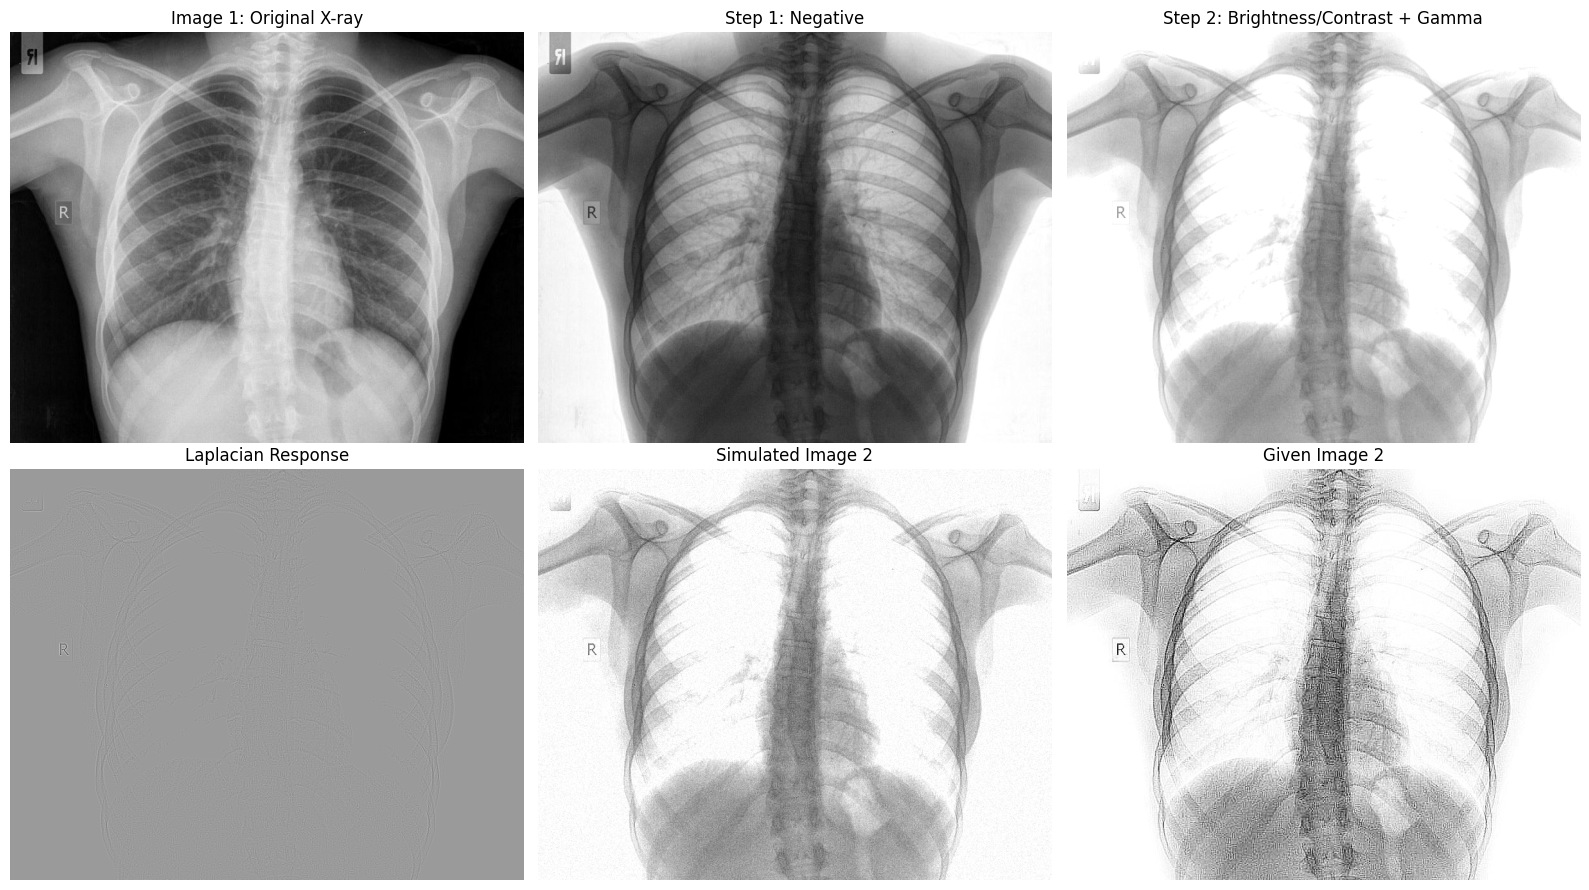

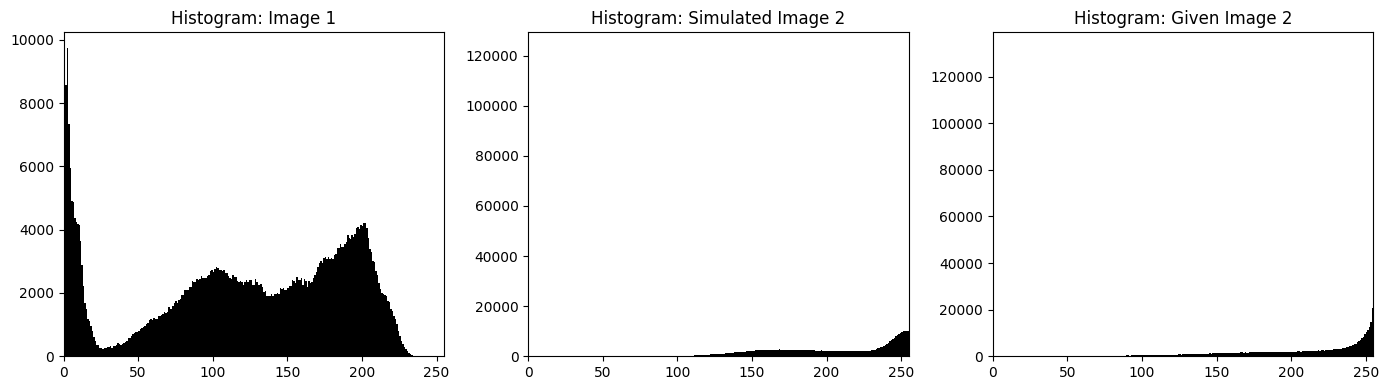

Forward model used:
1. I_neg = 255 - I1
2. I_gamma = 255 * (I_neg / 255)^gamma, with gamma < 1
3. I_bright = clip(alpha * I_gamma + beta, 0, 255)
4. I_sharp = I_bright + lambda * Laplacian(I_bright)
5. I2 = clip(I_sharp + Gaussian noise, 0, 255)

Parameters:
gamma = 0.6
alpha = 1.3
beta = 25
lambda = 0.45
noise sigma = 10.0

Simulated Image 2 statistics:
Min: 17
Max: 255
Mean: 216.22
Std: 42.11

Given Image 2 statistics:
Min: 0
Max: 255
Mean: 217.6
Std: 48.98


In [10]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ---------------------------------------------------------
# Exercise - Question (a)
# Guess and simulate the processing sequence Image 1 -> Image 2
# ---------------------------------------------------------

IMAGE1_PATH = Path(r"image_1.jpg")      # αρχική ακτινογραφία
IMAGE2_PATH = Path(r"image_2.jpg")      # επεξεργασμένη εικόνα, αν υπάρχει

def load_gray(path):
    image_bytes = np.fromfile(str(path), dtype=np.uint8)
    img = cv2.imdecode(image_bytes, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise ValueError(f"Could not load image: {path}")
    return img

I1 = load_gray(IMAGE1_PATH)

# Optional: load given Image 2 for visual comparison
I2_given = load_gray(IMAGE2_PATH) if IMAGE2_PATH.exists() else None

# ---------------------------------------------------------
# 1. Negative transformation
# I_neg(x,y) = 255 - I1(x,y)
# ---------------------------------------------------------
I_neg = 255 - I1

# ---------------------------------------------------------
# 2. Gamma correction for brightness enhancement
# For gamma < 1, mid/dark intensities become brighter
# ---------------------------------------------------------
gamma = 0.6
I_gamma = 255.0 * ((I_neg.astype(np.float32) / 255.0) ** gamma)

# ---------------------------------------------------------
# 3. Brightness / contrast increase
# I_bright = clip(alpha * I_gamma + beta, 0, 255)
# ---------------------------------------------------------
alpha = 1.3
beta = 25
I_bright = np.clip(alpha * I_gamma + beta, 0, 255)

# ---------------------------------------------------------
# 4. Laplacian sharpening / edge enhancement
# I_sharp = I_bright + lambda * Laplacian(I_bright)
# ---------------------------------------------------------
kernel_laplacian = np.array([[0, -1, 0],
                             [-1, 4, -1],
                             [0, -1, 0]], dtype=np.float32)

lap = cv2.filter2D(I_bright.astype(np.float32), cv2.CV_32F, kernel_laplacian)

lambda_value = 0.45
I_sharp = np.clip(I_bright + lambda_value * lap, 0, 255)

# ---------------------------------------------------------
# 5. Add fine Gaussian noise
# This models introduced or amplified noise
# ---------------------------------------------------------
np.random.seed(7)
noise_sigma = 10.0
noise = np.random.normal(0, noise_sigma, I_sharp.shape)

I2_simulated = np.clip(I_sharp + noise, 0, 255).astype(np.uint8)

# ---------------------------------------------------------
# 6. Display processing stages
# ---------------------------------------------------------
plt.figure(figsize=(16, 9))

plt.subplot(2, 3, 1)
plt.imshow(I1, cmap="gray", vmin=0, vmax=255)
plt.title("Image 1: Original X-ray")
plt.axis("off")

plt.subplot(2, 3, 2)
plt.imshow(I_neg, cmap="gray", vmin=0, vmax=255)
plt.title("Step 1: Negative")
plt.axis("off")

plt.subplot(2, 3, 3)
plt.imshow(I_bright.astype(np.uint8), cmap="gray", vmin=0, vmax=255)
plt.title("Step 2: Brightness/Contrast + Gamma")
plt.axis("off")

plt.subplot(2, 3, 4)
plt.imshow(cv2.normalize(lap, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8), cmap="gray")
plt.title("Laplacian Response")
plt.axis("off")

plt.subplot(2, 3, 5)
plt.imshow(I2_simulated, cmap="gray", vmin=0, vmax=255)
plt.title("Simulated Image 2")
plt.axis("off")

if I2_given is not None:
    plt.subplot(2, 3, 6)
    plt.imshow(I2_given, cmap="gray", vmin=0, vmax=255)
    plt.title("Given Image 2")
    plt.axis("off")

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 7. Histogram comparison
# ---------------------------------------------------------
plt.figure(figsize=(14, 4))

plt.subplot(1, 3, 1)
plt.hist(I1.ravel(), bins=256, range=(0, 256), color="black")
plt.title("Histogram: Image 1")
plt.xlim([0, 255])

plt.subplot(1, 3, 2)
plt.hist(I2_simulated.ravel(), bins=256, range=(0, 256), color="black")
plt.title("Histogram: Simulated Image 2")
plt.xlim([0, 255])

if I2_given is not None:
    plt.subplot(1, 3, 3)
    plt.hist(I2_given.ravel(), bins=256, range=(0, 256), color="black")
    plt.title("Histogram: Given Image 2")
    plt.xlim([0, 255])

plt.tight_layout()
plt.show()

print("Forward model used:")
print("1. I_neg = 255 - I1")
print("2. I_gamma = 255 * (I_neg / 255)^gamma, with gamma < 1")
print("3. I_bright = clip(alpha * I_gamma + beta, 0, 255)")
print("4. I_sharp = I_bright + lambda * Laplacian(I_bright)")
print("5. I2 = clip(I_sharp + Gaussian noise, 0, 255)")

print("\nParameters:")
print("gamma =", gamma)
print("alpha =", alpha)
print("beta =", beta)
print("lambda =", lambda_value)
print("noise sigma =", noise_sigma)

print("\nSimulated Image 2 statistics:")
print("Min:", I2_simulated.min())
print("Max:", I2_simulated.max())
print("Mean:", round(float(I2_simulated.mean()), 2))
print("Std:", round(float(I2_simulated.std()), 2))

if I2_given is not None:
    print("\nGiven Image 2 statistics:")
    print("Min:", I2_given.min())
    print("Max:", I2_given.max())
    print("Mean:", round(float(I2_given.mean()), 2))
    print("Std:", round(float(I2_given.std()), 2))


## 7. Histogram and Statistical Comparison

To evaluate whether the simulated Image 2 approximates the given Image 2, their histograms and basic statistics were compared.

The final simulated Image 2 produced the following statistics:

$$
\min = 17
$$

$$
\max = 255
$$

$$
\text{mean} = 216.22
$$

$$
\text{std} = 42.11
$$

The given Image 2 had the following statistics:

$$
\min = 0
$$

$$
\max = 255
$$

$$
\text{mean} = 217.6
$$

$$
\text{std} = 48.98
$$

The maximum value is identical:

$$
\max_{\text{simulated}}=\max_{\text{given}}=255
$$

This confirms that both images contain saturated bright pixels due to clipping.

The mean intensity is very close:

$$
217.6-216.22=1.38
$$

Therefore, the simulated image approximates the overall brightness of the given Image 2 very well.

The standard deviation is lower in the simulated image:

$$
48.98-42.11=6.87
$$

This means that the simulated image has slightly less contrast or intensity variation than the given Image 2.

The minimum value is also different:

$$
\min_{\text{simulated}}=17
$$

whereas:

$$
\min_{\text{given}}=0
$$

This indicates that the given Image 2 contains some darker extreme pixels that are not fully reproduced in the simulation.

---

## 8. Interpretation

The obtained results support the proposed processing sequence.

The transformation from Image 1 to Image 2 is most plausibly explained by:

1. Negative transformation, which inverts the X-ray intensities.
2. Gamma correction with \(\gamma<1\), which increases brightness.
3. Linear brightness and contrast enhancement, which increases the dynamic range and produces clipping.
4. Laplacian sharpening, which enhances anatomical edges and local structures.
5. Fine Gaussian noise or noise amplification, which explains the observed grainy texture.
6. Final clipping to the valid 8-bit range \([0,255]\).

The simulated Image 2 does not need to be identical to the given Image 2, because the exact parameters and original processing steps are unknown. However, the simulation successfully reproduces the main visual and statistical characteristics of Image 2:

- high brightness,
- negative-like appearance,
- saturated white regions,
- enhanced edges,
- fine-grained noise,
- full or near-full dynamic range,
- histogram shifted strongly toward high intensity values.


Σκέφτηκε για λίγα δευτερόλεπτα

Ναι — παρακάτω είναι έτοιμο Markdown στα αγγλικά για copy-paste στο Jupyter Notebook για το Question (b).

## Question (b) — Approximate Inverse Restoration Pipeline from Image 2 to Image 1

The goal of this part is to propose and implement an approximate inverse processing pipeline in order to recover an image similar to **Image 1**, starting from the given **Image 2**.

This inverse restoration cannot be perfect, because the transformation from Image 1 to Image 2 involved operations that are not fully reversible in practice, such as:

- clipping,
- saturation,
- noise amplification or noise addition,
- sharpening,
- nonlinear gray-level transformations.

Therefore, the objective is not to reconstruct Image 1 exactly, but to obtain a scientifically reasonable approximation of the original X-ray appearance.

The proposed inverse pipeline is:

$$
I_2
\rightarrow
I_{\text{denoised}}
\rightarrow
I_{\text{smooth}}
\rightarrow
I_{\text{inv-linear}}
\rightarrow
I_{\text{inv-gamma}}
\rightarrow
I_{\text{restored}}
\rightarrow
I_{\text{final}}
$$

where:

- \(I_2\) is the given processed image,
- \(I_{\text{final}}\) is the approximate restored estimate of Image 1.

---

## 1. Input Image

For the inverse restoration, the correct input is the **given Image 2** from the exercise, not the simulated Image 2 produced in Question (a).

Therefore:

$$
I_2 = \text{given Image 2}
$$

This is important because Question (b) asks for a pipeline that approximates Image 1 starting from the actual Image 2 provided in the exercise.

---

## 2. Median Denoising

Image 2 contains visible fine-grained noise. As a first step, median filtering is applied to reduce local noisy outliers while preserving edges better than a simple averaging filter.

A \(3 \times 3\) median filter is used:

$$
I_{\text{denoised}}(x,y)
=
\text{median}_{3 \times 3}
\left\{
I_2(i,j)
\right\}
$$

where \((i,j)\) are the pixels inside the \(3 \times 3\) neighborhood centered at \((x,y)\).

This step reduces isolated bright or dark noisy pixels without excessively blurring anatomical boundaries.

---

## 3. Mild Gaussian Smoothing / De-Sharpening

Because Image 2 appears sharpened, especially around anatomical edges, a mild Gaussian smoothing is applied to partially reduce the sharpening effect.

The Gaussian smoothing operation is:

$$
I_{\text{smooth}}
=
I_{\text{denoised}} * G_{\sigma}
$$

where \(*\) denotes convolution and \(G_{\sigma}\) is a Gaussian kernel.

The Gaussian kernel is:

$$
G_{\sigma}(x,y)
=
\frac{1}{2\pi\sigma^2}
\exp
\left(
-\frac{x^2+y^2}{2\sigma^2}
\right)
$$

In the implementation:

$$
\sigma = 0.9
$$

Therefore:

$$
I_{\text{smooth}}
=
I_{\text{denoised}} * G_{0.9}
$$

This operation performs mild low-pass filtering. Its purpose is to reduce excessive high-frequency components, including sharpened edges and noise.

---

## 4. Approximate Inverse Brightness / Contrast Transformation

In Question (a), the forward enhancement was assumed to include a linear brightness and contrast transformation of the form:

$$
I_{\text{bright}}(x,y)
=
\text{clip}
\left(
\alpha I_{\gamma}(x,y)+\beta,\ 0,\ 255
\right)
$$

Ignoring clipping for the inverse approximation, the inverse linear transformation is:

$$
I_{\text{inv-linear}}(x,y)
=
\frac{
I_{\text{smooth}}(x,y)-\beta
}{\alpha}
$$

In the implementation:

$$
\alpha = 1.25
$$

and:

$$
\beta = 25
$$

Thus:

$$
I_{\text{inv-linear}}(x,y)
=
\frac{
I_{\text{smooth}}(x,y)-25
}{1.25}
$$

After this operation, clipping is applied:

$$
I_{\text{inv-linear}}(x,y)
=
\text{clip}
\left(
I_{\text{inv-linear}}(x,y),\ 0,\ 255
\right)
$$

This step attempts to undo the brightness and contrast increase applied during the forward transformation.

---

## 5. Approximate Inverse Gamma Correction

The forward gamma correction was assumed to be:

$$
s
=
255
\left(
\frac{r}{255}
\right)^{\gamma}
$$

where \(r\) is the input gray-level value and \(s\) is the gamma-corrected output value.

The inverse gamma correction is therefore:

$$
r
=
255
\left(
\frac{s}{255}
\right)^{1/\gamma}
$$

In the inverse restoration pipeline:

$$
s = I_{\text{inv-linear}}
$$

Therefore:

$$
I_{\text{inv-gamma}}(x,y)
=
255
\left(
\frac{
I_{\text{inv-linear}}(x,y)
}{255}
\right)^{1/\gamma}
$$

Using the forward gamma value:

$$
\gamma = 0.6
$$

the inverse gamma exponent is:

$$
\frac{1}{\gamma}
=
\frac{1}{0.6}
\approx 1.67
$$

Thus:

$$
I_{\text{inv-gamma}}(x,y)
=
255
\left(
\frac{
I_{\text{inv-linear}}(x,y)
}{255}
\right)^{1/0.6}
$$

This step attempts to reverse the nonlinear brightening caused by gamma correction in the forward pipeline.

---

## 6. Negative Inversion

Image 2 has a negative-like appearance. Therefore, after approximately undoing brightness, contrast, and gamma correction, a negative inversion is applied:

$$
I_{\text{restored}}(x,y)
=
255
-
I_{\text{inv-gamma}}(x,y)
$$

This operation converts the image back toward the normal X-ray appearance.

In particular:

- bright lung regions in Image 2 become dark again,
- darker bony structures in the negative-like image become brighter again,
- the overall image becomes closer to the original radiographic appearance.

For example, if a lung pixel in the processed negative-like image has value:

$$
I_{\text{inv-gamma}}(\text{lung}) = 220
$$

then after negative inversion:

$$
I_{\text{restored}}(\text{lung})
=
255-220
=
35
$$

Thus, the lungs become dark again, as expected in the original X-ray.

---

## 7. Final Percentile Contrast Adjustment

After the inverse operations, the restored image may not have an optimal intensity distribution. Therefore, a final robust contrast adjustment is applied using percentiles.

The 1st and 99th percentiles of \(I_{\text{restored}}\) are computed:

$$
P_1 = \text{percentile}_{1}(I_{\text{restored}})
$$

$$
P_{99} = \text{percentile}_{99}(I_{\text{restored}})
$$

Then the image is normalized using:

$$
I_{\text{norm}}(x,y)
=
\frac{
I_{\text{restored}}(x,y)-P_1
}{
P_{99}-P_1+\epsilon
}
$$

where:

$$
\epsilon = 10^{-8}
$$

The small constant \(\epsilon\) prevents division by zero.

Then clipping is applied:

$$
I_{\text{norm}}(x,y)
=
\text{clip}
\left(
I_{\text{norm}}(x,y),\ 0,\ 1
\right)
$$

Finally, the normalized image is mapped to the range \([0,240]\):

$$
I_{\text{final}}(x,y)
=
240 \cdot I_{\text{norm}}(x,y)
$$

Therefore, the full final adjustment is:

$$
I_{\text{final}}(x,y)
=
240
\cdot
\text{clip}
\left(
\frac{
I_{\text{restored}}(x,y)-P_1
}{
P_{99}-P_1+\epsilon
},
0,
1
\right)
$$

The range \([0,240]\) is used instead of \([0,255]\) because the original Image 1 does not appear strongly saturated at pure white. This produces a more natural X-ray-like appearance.

The percentile-based contrast adjustment is more robust than simple min-max normalization because it ignores extreme outlier pixels. Values below \(P_1\) are clipped to 0, while values above \(P_{99}\) are clipped to the maximum output value.

---

## 8. Complete Mathematical Inverse Pipeline

The complete inverse restoration model can be summarized as follows.

First, denoising:

$$
I_{\text{denoised}}(x,y)
=
\text{median}_{3 \times 3}
\left(
I_2(x,y)
\right)
$$

Then mild Gaussian smoothing:

$$
I_{\text{smooth}}
=
I_{\text{denoised}} * G_{0.9}
$$

Then inverse brightness and contrast correction:

$$
I_{\text{inv-linear}}(x,y)
=
\text{clip}
\left(
\frac{
I_{\text{smooth}}(x,y)-25
}{1.25},
0,
255
\right)
$$

Then inverse gamma correction:

$$
I_{\text{inv-gamma}}(x,y)
=
255
\left(
\frac{
I_{\text{inv-linear}}(x,y)
}{255}
\right)^{1/0.6}
$$

Then negative inversion:

$$
I_{\text{restored}}(x,y)
=
255
-
I_{\text{inv-gamma}}(x,y)
$$

Then percentile contrast adjustment:

$$
I_{\text{final}}(x,y)
=
240
\cdot
\text{clip}
\left(
\frac{
I_{\text{restored}}(x,y)-P_1
}{
P_{99}-P_1+10^{-8}
},
0,
1
\right)
$$


Loaded given Image 2 from file.


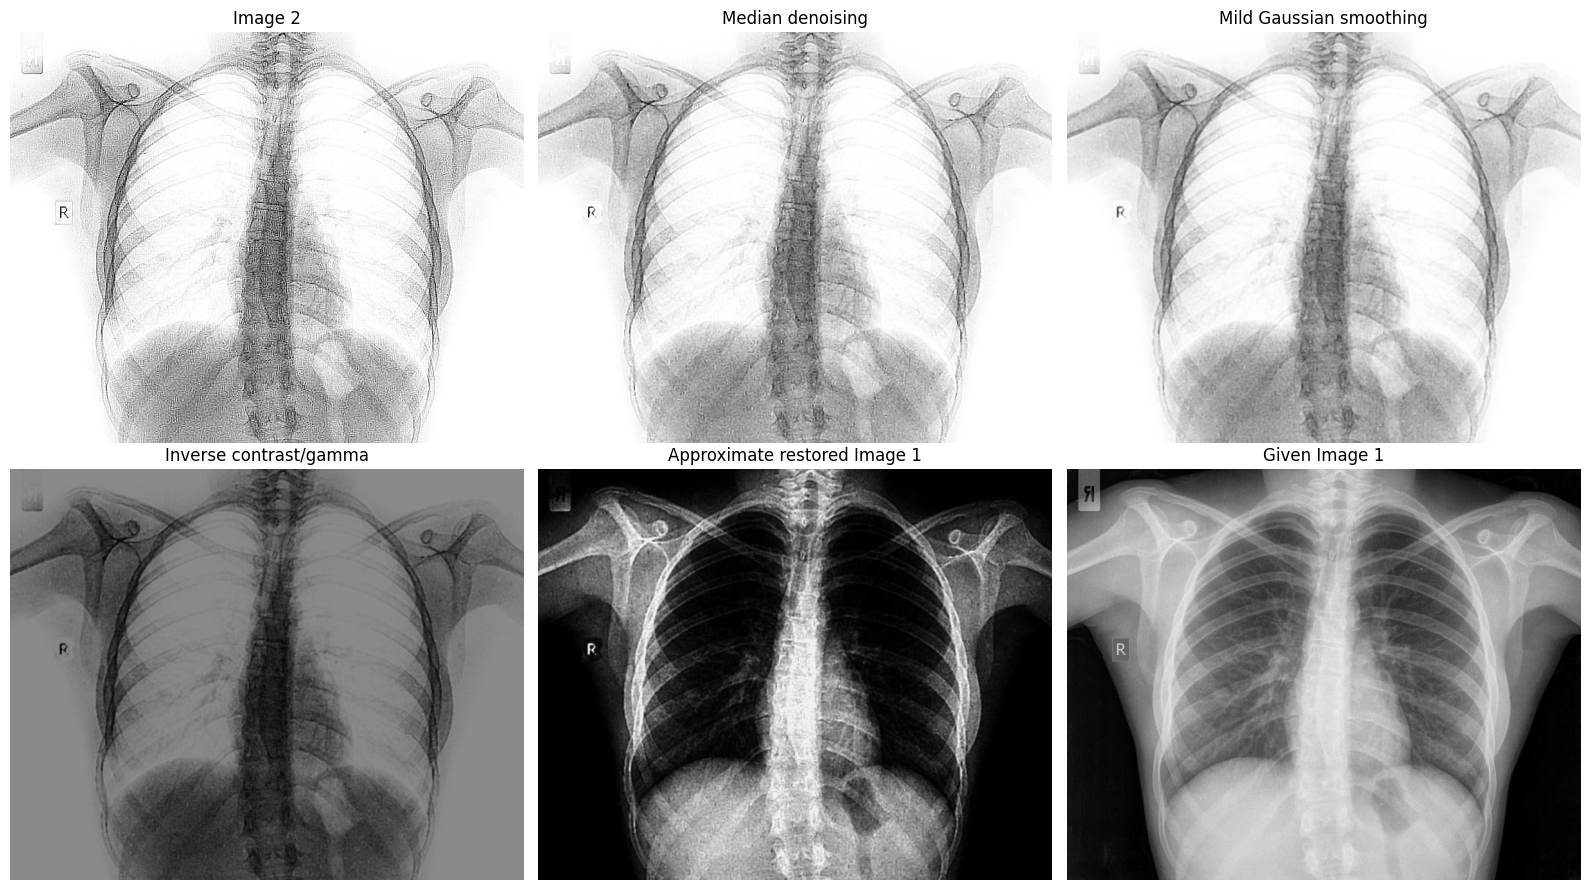

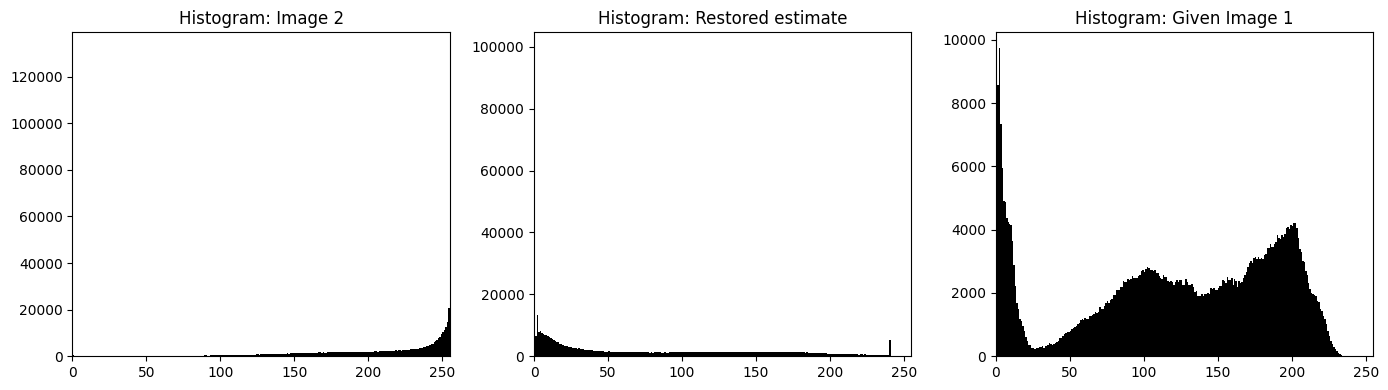

Inverse restoration pipeline:
1. Median denoising
2. Mild Gaussian smoothing / de-sharpening
3. Approximate inverse brightness-contrast transform
4. Approximate inverse gamma correction
5. Negative inversion
6. Final percentile contrast adjustment

Restored estimate statistics:
Min: 0
Max: 240
Mean: 65.96
Std: 71.39

Given Image 1 statistics:
Min: 0
Max: 240
Mean: 121.46
Std: 68.2

Note:
The restoration is approximate because clipping, saturation, noise, and sharpening are not perfectly reversible.


In [16]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ---------------------------------------------------------
# Exercise - Question (b)
# Approximate inverse restoration Image 2 -> Image 1
# Works either with I2_simulated from Question (a),
# or with an image file if you give the correct path.
# ---------------------------------------------------------

IMAGE2_PATH = Path(r"image_2.jpg")
IMAGE1_PATH = Path(r"image_1.jpg")

def load_gray(path):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(
            f"File not found: {path}\n"
            f"Current working directory is: {Path.cwd()}\n"
            "Either put the image in this folder or use the full absolute path."
        )

    image_bytes = np.fromfile(str(path), dtype=np.uint8)
    img = cv2.imdecode(image_bytes, cv2.IMREAD_GRAYSCALE)

    if img is None:
        raise ValueError(f"Could not load image: {path}")

    return img

# ---------------------------------------------------------
# Load Image 2
I2 = load_gray(IMAGE2_PATH)
print("Loaded given Image 2 from file.")

# Optional Image 1 for comparison
if IMAGE1_PATH.exists():
    I1_given = load_gray(IMAGE1_PATH)
else:
    I1_given = None
    print("Image 1 file not found. Restoration will be shown without direct comparison.")

# ---------------------------------------------------------
# 1. Denoising
# ---------------------------------------------------------
I_denoised = cv2.medianBlur(I2, 3).astype(np.float32)

# ---------------------------------------------------------
# 2. Mild low-pass filtering / de-sharpening
# ---------------------------------------------------------
sigma_smooth = 0.9
I_smooth = cv2.GaussianBlur(
    I_denoised,
    (0, 0),
    sigmaX=sigma_smooth,
    sigmaY=sigma_smooth
)

# ---------------------------------------------------------
# 3. Approximate inverse brightness / contrast transform
# Forward assumed:
# I_bright = alpha * I_neg + beta
# Inverse:
# I_neg ~= (I_smooth - beta) / alpha
# ---------------------------------------------------------
alpha = 1.3
beta = 25

I_inv_linear = (I_smooth - beta) / alpha
I_inv_linear = np.clip(I_inv_linear, 0, 255)

# ---------------------------------------------------------
# 4. Approximate inverse gamma correction
# Forward:
# s = r^gamma, gamma < 1
# Inverse:
# r = s^(1/gamma)
# ---------------------------------------------------------
gamma_forward = 0.6

r = I_inv_linear / 255.0
I_inv_gamma = 255.0 * np.power(np.clip(r, 0, 1), 1.0 / gamma_forward)
I_inv_gamma = np.clip(I_inv_gamma, 0, 255)

# ---------------------------------------------------------
# 5. Negative inversion
# ---------------------------------------------------------
I_restored = 255.0 - I_inv_gamma
I_restored = np.clip(I_restored, 0, 255)

# ---------------------------------------------------------
# 6. Final percentile contrast adjustment
# Map robust intensity range to [0, 240]
# ---------------------------------------------------------
p_low, p_high = np.percentile(I_restored, (1, 99))

I_final = (I_restored - p_low) / (p_high - p_low + 1e-8)
I_final = np.clip(I_final, 0, 1)
I_final = (I_final * 240.0).astype(np.uint8)

# ---------------------------------------------------------
# 7. Display restoration stages
# ---------------------------------------------------------
plt.figure(figsize=(16, 9))

plt.subplot(2, 3, 1)
plt.imshow(I2, cmap="gray", vmin=0, vmax=255)
plt.title("Image 2")
plt.axis("off")

plt.subplot(2, 3, 2)
plt.imshow(I_denoised.astype(np.uint8), cmap="gray", vmin=0, vmax=255)
plt.title("Median denoising")
plt.axis("off")

plt.subplot(2, 3, 3)
plt.imshow(I_smooth.astype(np.uint8), cmap="gray", vmin=0, vmax=255)
plt.title("Mild Gaussian smoothing")
plt.axis("off")

plt.subplot(2, 3, 4)
plt.imshow(I_inv_gamma.astype(np.uint8), cmap="gray", vmin=0, vmax=255)
plt.title("Inverse contrast/gamma")
plt.axis("off")

plt.subplot(2, 3, 5)
plt.imshow(I_final, cmap="gray", vmin=0, vmax=255)
plt.title("Approximate restored Image 1")
plt.axis("off")

if I1_given is not None:
    plt.subplot(2, 3, 6)
    plt.imshow(I1_given, cmap="gray", vmin=0, vmax=255)
    plt.title("Given Image 1")
    plt.axis("off")

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 8. Histogram comparison
# ---------------------------------------------------------
plt.figure(figsize=(14, 4))

plt.subplot(1, 3, 1)
plt.hist(I2.ravel(), bins=256, range=(0, 256), color="black")
plt.title("Histogram: Image 2")
plt.xlim([0, 255])

plt.subplot(1, 3, 2)
plt.hist(I_final.ravel(), bins=256, range=(0, 256), color="black")
plt.title("Histogram: Restored estimate")
plt.xlim([0, 255])

if I1_given is not None:
    plt.subplot(1, 3, 3)
    plt.hist(I1_given.ravel(), bins=256, range=(0, 256), color="black")
    plt.title("Histogram: Given Image 1")
    plt.xlim([0, 255])

plt.tight_layout()
plt.show()

print("Inverse restoration pipeline:")
print("1. Median denoising")
print("2. Mild Gaussian smoothing / de-sharpening")
print("3. Approximate inverse brightness-contrast transform")
print("4. Approximate inverse gamma correction")
print("5. Negative inversion")
print("6. Final percentile contrast adjustment")

print("\nRestored estimate statistics:")
print("Min:", I_final.min())
print("Max:", I_final.max())
print("Mean:", round(float(I_final.mean()), 2))
print("Std:", round(float(I_final.std()), 2))

if I1_given is not None:
    print("\nGiven Image 1 statistics:")
    print("Min:", I1_given.min())
    print("Max:", I1_given.max())
    print("Mean:", round(float(I1_given.mean()), 2))
    print("Std:", round(float(I1_given.std()), 2))

print("\nNote:")
print("The restoration is approximate because clipping, saturation, noise, and sharpening are not perfectly reversible.")


## 9. Histogram and Statistical Comparison

The final restored estimate was compared with the given Image 1 using histograms and basic statistics.

The restored estimate produced the following statistics:

$$
\min_{\text{restored}} = 0
$$

$$
\max_{\text{restored}} = 240
$$

$$
\text{mean}_{\text{restored}} = 65.96
$$

$$
\text{std}_{\text{restored}} = 71.39
$$

The given Image 1 had the following statistics:

$$
\min_{\text{given}} = 0
$$

$$
\max_{\text{given}} = 240
$$

$$
\text{mean}_{\text{given}} = 121.46
$$

$$
\text{std}_{\text{given}} = 68.2
$$

---

## 10. Interpretation of the Results

The minimum values match:

$$
\min_{\text{restored}}
=
\min_{\text{given}}
=
0
$$

This means that the restored estimate successfully recovers fully dark regions.

The maximum values also match:

$$
\max_{\text{restored}}
=
\max_{\text{given}}
=
240
$$

This is expected because the final percentile adjustment maps the restored image to the range \([0,240]\), matching the observed upper intensity range of the original Image 1.

The standard deviations are relatively close:

$$
\text{std}_{\text{restored}} = 71.39
$$

$$
\text{std}_{\text{given}} = 68.2
$$

The difference is:

$$
71.39 - 68.2 = 3.19
$$

This indicates that the restored estimate has a similar level of intensity variation or contrast compared with the original Image 1.

However, the mean intensity is significantly lower in the restored estimate:

$$
\text{mean}_{\text{restored}} = 65.96
$$

whereas:

$$
\text{mean}_{\text{given}} = 121.46
$$

The difference is:

$$
121.46 - 65.96 = 55.5
$$

This shows that the restored image is darker on average than the given Image 1.

This difference is expected because the original transformation caused saturation, clipping, noise amplification, and sharpening. Once multiple different intensity values have been clipped to 255 in Image 2, the original gray-level information cannot be perfectly recovered.

---

## 11. Why the Restoration Is Only Approximate

The inverse restoration is not exact because some steps in the forward transformation are not perfectly reversible.

First, clipping causes information loss:

$$
I(x,y)>255
\Rightarrow
I(x,y)=255
$$

Once different values are mapped to the same value 255, their original values cannot be uniquely recovered.

Second, saturation compresses bright regions into the same maximum value. Therefore, local contrast in those areas is lost.

Third, noise cannot be removed perfectly. If Image 2 contains noise:

$$
G(u,v)
=
H(u,v)F(u,v)+N(u,v)
$$

then inverse filtering would give:

$$
\hat{F}(u,v)
=
\frac{G(u,v)}{H(u,v)}
=
F(u,v)
+
\frac{N(u,v)}{H(u,v)}
$$

If \(H(u,v)\) is small, the noise term becomes large:

$$
\frac{N(u,v)}{H(u,v)}
\rightarrow
\text{large}
$$

Therefore, a perfect inversion would strongly amplify noise.

Fourth, sharpening is theoretically invertible only under restrictive conditions. If sharpening is modeled as:

$$
g(x,y)=f(x,y)*h(x,y)
$$

then in the frequency domain:

$$
G(u,v)=F(u,v)H(u,v)
$$

A theoretical inverse would be:

$$
F(u,v)=\frac{G(u,v)}{H(u,v)}
$$

However, this is stable only if:

$$
H(u,v)\neq 0
$$

for all frequencies.

If:

$$
H(u,v)=0
$$

then the corresponding frequency component is lost and cannot be recovered.

If:

$$
H(u,v)\approx 0
$$

then inverse filtering strongly amplifies noise.

Therefore, instead of performing unstable full inverse filtering, the implemented pipeline uses median denoising and mild Gaussian smoothing as a practical approximate de-sharpening strategy.

---

## 12. Final Conclusion

The proposed inverse restoration pipeline is scientifically reasonable because it applies the approximate inverse of the assumed forward transformations from Question (a).

The pipeline performs:

1. median denoising,
2. mild Gaussian smoothing for de-sharpening,
3. inverse brightness and contrast correction,
4. inverse gamma correction,
5. negative inversion,
6. final percentile contrast adjustment.

The restored image successfully recovers several important properties of Image 1:

- it returns from a bright negative-like appearance to a normal X-ray-like appearance,
- it restores dark regions,
- it avoids excessive white saturation,
- it approximately matches the dynamic range of Image 1,
- it produces a contrast level close to that of the original image.

However, the restored image is darker on average than the given Image 1. This is acceptable and expected because the forward transformation introduced non-reversible effects, especially clipping, saturation, noise, and sharpening.

Therefore, the result should be interpreted as an approximate restoration rather than an exact reconstruction.